# People happiness

How happy the people living in a grid cell say they are — operationalised as the [Cantril ladder](https://news.gallup.com/poll/122453/understanding-gallup-uses-cantril-scale.aspx) life-evaluation score published in the annual **[World Happiness Report](https://worldhappiness.report/)**. Respondents place themselves on an 11-rung ladder from `0` ("worst possible life") to `10` ("best possible life"); the WHR reports the country mean of a rolling **3-year average**, which is the primary happiness metric everyone else in the well-being literature also uses. 🔴 **Tier C** in `DATASETS.md`: this is a survey mean, so cells are country-flat by construction.

## Why no finer-grained data

I searched for anything that would let this layer break out of the country-flat pattern the way ACLED does for `34_human_freedom`, and there simply is no global sub-national life-evaluation dataset:

* **[Human Flourishing Geographic Index (HFGI)](https://arxiv.org/pdf/2511.10542)** — a 2025 arXiv release covers happiness + life satisfaction at US county / state level, inferred from 2.6 B geo-referenced tweets. Impressive resolution but US-only, so useless as a global atlas layer.
* **OECD Regional Well-Being** — publishes life-satisfaction at TL2/TL3 sub-national units, but only for ~40 OECD + partner countries. Same coverage gap as OECD BLI.
* **European Social Survey (ESS)** — biennial, sub-national (NUTS-1/NUTS-2), Cantril-adjacent well-being items, ~30 European countries. Would only sharpen the corner of the map that is already best-served.
* **World Values Survey Wave 7 (2017–2022)** — has `A008` ("feeling of happiness") and `A170` (life satisfaction) for ~90 countries, but samples are sub-nationally representative for only a handful of large countries; using the raw point locations would over-fit a few thousand respondents onto a global grid.
* **Global Data Lab SHDI (used by `36_education`)** — has no life-satisfaction sub-index; only Health/Education/Income dimensions of HDI.

None of these are a global sub-national replacement for the Cantril ladder, so we accept a country-flat layer and mark it Tier C.

## What we do use

The [**World Happiness Report 2026** Figure 2.1 dataset](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) — the WHR is powered by the Gallup World Poll and republishes country-year values under a redistribution-permitted licence. The `Life evaluation (3-year average)` column is the **raw** Cantril ladder mean on a `[0, 10]` scale (unlike the `Explained by: <dimension>` columns, which are regression-decomposition contributions in "happiness units"). WHR 2026 uses the 2023–2025 pooling window. We take the latest available year per country, map WHR names to Natural Earth ISO3 with a small alias table, and rasterise via `load_country_mask` — the same pattern `34_human_freedom` and `35_corruption` use.

Higher values already mean *happier population*, so **no sign inversion**. Ocean cells are masked via `is_land` from `grid.nc`; countries WHR does not cover (Kosovo, several Pacific/Caribbean/Gulf micro-states, Somaliland) stay `NaN` and `weighted_score`'s per-cell renormalisation absorbs the gap without penalising the cell.

In [1]:
import pandas as pd
import xarray as xr

from common import RAW_DIR, download, load_country_mask, load_grid, plot_map, save_variable

VARIABLE = 'people_happiness'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch WHR 2026 Figure 2.1 workbook

Single ~130 KB `.xlsx` from `files.worldhappiness.report`. The URL is stable across the WHR release (they version by year, not by patch), so we cache once and skip re-download on subsequent runs. Bump the year in `WHR_URL` when a newer report appears.

In [2]:
WHR_URL = 'https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx'
whr_path = variable_raw / 'WHR26_Data_Figure_2.1.xlsx'

if not whr_path.exists():
    await download(WHR_URL, whr_path)

print(f'{whr_path.name}: {whr_path.stat().st_size / 1024:.0f} KB')

WHR26_Data_Figure_2.1.xlsx: 130 KB


## 2. Latest Cantril-ladder score per country → ISO3

The workbook has one row per `(Country name, Year)` from 2011 onward, with `Life evaluation (3-year average)` as the raw Cantril mean on `[0, 10]`. We drop rows without a value, take the most recent year per country, and translate WHR country names to Natural Earth's ISO3 codes so we can rasterise via the shared country mask.

The alias table below covers every mismatch between WHR's naming ("Türkiye", "Republic of Korea", "State of Palestine", "Viet Nam", "Côte d'Ivoire" with a typographic apostrophe, ...) and the Natural Earth 50m admin_0 spelling `03_region_mask.ipynb` uses. WHR uses these long-form names consistently, so a static dict is enough — no fuzzy matching required. Countries WHR reports on but that are not in the Natural Earth mask (**North Cyprus**, **Kosovo** — same gap `34_human_freedom` and `35_corruption` document) are logged and dropped.

In [3]:
# The raw Cantril ladder mean on [0, 10], published as a rolling 3-year average.
# Unlike the "Explained by: <dimension>" columns (which are regression contributions),
# this is directly the survey response scale — no affine transform to unwind.
LADDER_COL = 'Life evaluation (3-year average)'

# WHR name → ISO3. Only names that do NOT match Natural Earth's admin_0 NAME exactly
# (NE abbreviates "S. Sudan", "Dominican Rep.", "Bosnia and Herz.", "Central African Rep."
# where WHR spells them out; WHR also uses long-form UN names for Iran, Russia, etc.).
WHR_TO_ISO3 = {
    'Bolivia (Plurinational State of)':      'BOL',
    'Bosnia and Herzegovina':                 'BIH',
    'Central African Republic':               'CAF',
    'Congo':                                  'COG',  # Republic of Congo / Brazzaville
    'DR Congo':                               'COD',
    "Côte d’Ivoire":                    'CIV',  # typographic apostrophe in WHR
    "Côte d'Ivoire":                    'CIV',  # ASCII fallback
    'Dominican Republic':                     'DOM',
    'Eswatini':                               'SWZ',
    'Swaziland':                              'SWZ',
    'Hong Kong SAR of China':                 'HKG',
    'Iran (Islamic Republic of)':             'IRN',
    'Lao PDR':                                'LAO',
    "Lao People's Democratic Republic":       'LAO',
    'Republic of Korea':                      'KOR',
    'Republic of Moldova':                    'MDA',
    'Russian Federation':                     'RUS',
    'South Sudan':                            'SSD',
    'State of Palestine':                     'PSE',
    'Palestinian Territories':                'PSE',
    'Syrian Arab Republic':                   'SYR',
    'Taiwan Province of China':               'TWN',
    'Tanzania':                               'TZA',
    'United Republic of Tanzania':            'TZA',
    'Türkiye':                          'TUR',
    'Turkey':                                 'TUR',
    'United States':                          'USA',
    'United Kingdom':                         'GBR',
    'Venezuela (Bolivarian Republic of)':     'VEN',
    'Viet Nam':                               'VNM',
    # WHR reports these but Natural Earth 50m admin_0 does not carry a polygon for them
    # (same as human_freedom / corruption). Mapping to '' drops them cleanly on the join.
    'North Cyprus':                           '',
    'Kosovo':                                 '',
    'Somaliland region':                      '',
    'Somaliland Region':                      '',  # WHR2026 Cantril rows use capital R
}

whr = pd.read_excel(whr_path).dropna(subset=[LADDER_COL])
latest = whr.sort_values('Year').groupby('Country name', as_index=False).tail(1)

# Exact match against Natural Earth NAME via the shared country lookup, with the alias
# table above for WHR-specific spellings.
from common import load_country_lookup
ne_name_to_iso3 = dict(zip(load_country_lookup()['NAME'], load_country_lookup()['ISO3']))

def to_iso3(name):
    if name in WHR_TO_ISO3:
        return WHR_TO_ISO3[name] or None
    return ne_name_to_iso3.get(name)

latest = latest.assign(ISO3=latest['Country name'].map(to_iso3))

unmatched = latest[latest['ISO3'].isna()]['Country name'].tolist()
if unmatched:
    print(f'unmatched ({len(unmatched)}): {unmatched}')

# Some WHR names collapse onto the same ISO3 (e.g. 'Eswatini' and 'Swaziland' → SWZ).
# Keep the newer observation per ISO3 so a stale alias never overrides fresh data.
scores = (
    latest.dropna(subset=['ISO3'])
          .sort_values('Year')
          .drop_duplicates(subset='ISO3', keep='last')
          .set_index('ISO3')[['Country name', 'Year', LADDER_COL]]
          .rename(columns={LADDER_COL: 'happiness'})
)
print(f'{len(scores)} countries with a Cantril ladder score '
      f'(years {int(scores["Year"].min())}–{int(scores["Year"].max())}, '
      f'range [{scores["happiness"].min():.3f}, {scores["happiness"].max():.3f}])')
scores.head()

unmatched (3): ['Somaliland Region', 'North Cyprus', 'Kosovo']
164 countries with a Cantril ladder score (years 2011–2025, range [1.446, 7.764])


,Country name,Year,happiness
ISO3,,,
GUY,Guyana,2011,5.993
CUB,Cuba,2011,5.418
DJI,Djibouti,2014,4.369
SUR,Suriname,2015,6.269
PRI,Puerto Rico,2015,7.039


## 3. Rasterise onto the atlas grid

Standard country-mask join: `load_country_mask` returns an ISO3 string per grid cell (built by `03_region_mask.ipynb` from Natural Earth 50m admin_0), we map each cell to its country's `happiness`, and reshape back onto the `(lat, lon)` grid. Higher = happier already matches the atlas convention, so **no sign inversion**.

In [4]:
grid = load_grid()
iso_per_cell = load_country_mask()

raster = (
    pd.Series(iso_per_cell.values.ravel())
      .map(scores['happiness'])
      .to_numpy(dtype='float32')
      .reshape(iso_per_cell.shape)
)

values = (
    xr.DataArray(
        raster,
        coords=iso_per_cell.coords,
        dims=iso_per_cell.dims,
        name=VARIABLE,
    )
    .where(grid.is_land == 1)
)
values.attrs['source'] = (
    f'World Happiness Report 2026, "{LADDER_COL}" '
    f'(latest year per country, up to {int(scores["Year"].max())})'
)
values.attrs['units'] = 'Cantril ladder [0, 10], 3-year rolling average'
values.attrs['orientation'] = 'higher = happier (matches atlas convention; no inversion needed)'

land_cells = int((grid.is_land == 1).sum())
covered = int(values.notnull().sum())
print(f'{covered}/{land_cells} land cells covered ({100 * covered / land_cells:.1f}%)')
print(f'values range: {float(values.min()):.3f} .. {float(values.max()):.3f}')

63788/68294 land cells covered (93.4%)
values range: 1.446 .. 7.764


## 4. Plot

<Axes: title={'center': 'People happiness (WHR Cantril ladder)'}, xlabel='longitude', ylabel='latitude'>

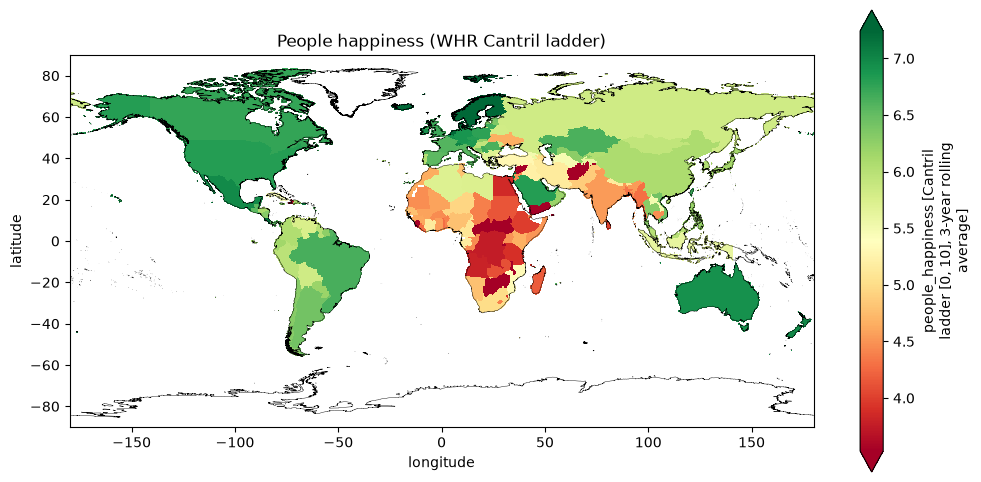

In [5]:
plot_map(values, cmap='RdYlGn', robust=True, title='People happiness (WHR Cantril ladder)')

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/people_happiness.nc
